# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EgeGln365/FlyRank_AI_Internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

data_path = Path("../../data/raw/content_refresh_anonymized.csv").resolve()

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Shape: {df.shape}")

Dataset path: /Users/egegulunay/PROJECTS/FlyRank_AI_Internship/data/raw/content_refresh_anonymized.csv
Shape: (30000, 44)


In [3]:
pd.set_option("display.max_columns", None)

In [3]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

In [4]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,0.991933,0.204500,4.033500,61.454033,13.096333,1429.058733,4.933867,14.114267,1783.078500,5.435100,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,4.359576,1.363601,22.335179,32.689245,17.307759,5643.852081,23.929393,39.036371,6150.429511,28.358673,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,31.000000,2.000000,10.000000,0.000000,0.000000,19.000000,0.000000,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,0.000000,0.000000,1.000000,81.000000,6.000000,139.000000,0.000000,3.000000,210.000000,0.000000,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,1.000000,0.000000,3.000000,88.000000,16.000000,768.000000,2.000000,12.000000,1143.000000,2.000000,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,290.000000,64.000000,2605.000000,88.000000,90.000000,238796.000000,1176.000000,1081.000000,218786.000000,1627.000000,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [8]:
(df.isna().mean()*100).sort_values(ascending=False)


provider_used             71.460000
char_count                25.663333
word_count                25.663333
word_count_tier           25.663333
char_count_tier           25.663333
model_used                19.110000
trend_pct                 11.293333
competition_level          8.700000
cpc                        8.226667
competition                8.226667
search_volume              8.226667
main_intent                7.913333
scroll_rate                0.416667
age_tier                   0.000000
ctr                        0.000000
age_tier_order             0.000000
days_since_last_update     0.000000
freshness_tier             0.000000
impression_tier            0.000000
avg_position               0.000000
engagement_rate            0.000000
ai_traffic_pct             0.000000
sessions_prev_30d          0.000000
position_tier              0.000000
trend_direction            0.000000
content_age_days           0.000000
content_id                 0.000000
clicks_prev_30d            0

In [9]:
df["trend_direction"].value_counts()


trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

This lane is primarily a ranking and scoring task.

The goal is to assign each content item a refresh-priority score and rank
the pages from the highest to the lowest opportunity. A classification
model may first estimate the probability that a page is declining, but
the final business output is not only a yes/no prediction. The final
output is a ranked list that helps the content team decide which pages
should be reviewed or refreshed first.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one  typing sentences here breaks Run All.


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

The prediction target is `is_declining_label`.

It equals 1 when `trend_direction` is `"down"` and 0 otherwise. This is
a rule-defined proxy label rather than a directly observed business
outcome. The dataset does not contain a human-reviewed label saying
whether a page truly needs a refresh, so a meaningful decline in recent
search impressions is used as an approximation.

Because the target is derived from `trend_direction` and `trend_pct`,
these columns must not be used as model features.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

df["is_declining_label"] = (
    df["trend_direction"].eq("down").astype(int)
)

target_counts = df["is_declining_label"].value_counts()
target_rate = df["is_declining_label"].mean()

print(target_counts)
print(f"Declining content rate: {target_rate:.2%}")

is_declining_label
1    16262
0    13738
Name: count, dtype: int64
Declining content rate: 54.21%


## 3. Success metric

*One metric you can defend. What number means 'good'?*

The primary success metric is Precision@50.

It measures the proportion of truly declining content items among the
top 50 pages recommended by the model. This metric matches the business
workflow because the content team has limited capacity and can only
review a small number of pages.

The baseline Precision@50 is approximately 0.34. I would consider a
Precision@50 of at least 0.50 a useful initial result because it would
mean that at least 25 of the top 50 recommendations are truly declining.
The model should also consistently outperform the baseline on held-out
clients.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

The unit of analysis is one content item, or one page.

Each dataframe row represents a single pseudonymized content page and
contains its keyword context, content properties, 90-day search and
analytics performance, and recent trend information.

The prediction and ranking are therefore produced at the content-item
level. `content_id` identifies the page, while `client_id` identifies
the pseudonymized client. These identifiers are used for grouping and
validation, not as model features.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
lane_columns = [
    "content_id",
    "client_id",
    "search_volume",
    "competition",
    "cpc",
    "content_type",
    "main_intent",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "sessions_90d",
    "engagement_rate",
    "trend_direction",
]

lane_df = df[lane_columns].copy()

display(lane_df.head())
print("Lane dataframe shape:", lane_df.shape) 

#informaiton: trend_direction will not use in features

,content_id,client_id,search_volume,competition,cpc,content_type,main_intent,content_age_days,days_since_last_update,impressions_90d,clicks_90d,ctr,avg_position,sessions_90d,engagement_rate,trend_direction
0,content_304f48230142,client_f369cb89fc,10.0,0.67,2.05,keyword article,transactional,187,20,3803,29,0.76,10.6,17,5.88,down
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,0.05,keyword article,informational,445,25,15320,7,0.05,20.3,9,0.00,down
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,0.00,keyword article,informational,141,20,12581,11,0.09,36.5,11,0.00,down
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,0.00,keyword article,commercial,463,22,11751,58,0.49,6.2,78,1.28,stable
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,0.00,keyword article,informational,263,14,19140,24,0.13,44.0,145,0.00,down


Lane dataframe shape: (30000, 16)


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

A fixed rule is too limited because refresh priority depends on several
interacting signals rather than one threshold.

For example, an old page is not automatically a strong refresh
opportunity. Its priority also depends on search demand, commercial
value, impressions, clicks, CTR, ranking position, engagement, content
type, and time since the last update. The importance of one feature may
also change depending on the values of other features.

A rule such as “refresh every page older than 365 days” would create many
false positives and miss newer pages with valuable declining traffic.
Machine learning can learn nonlinear relationships and interactions
between these signals and produce a more flexible priority score.

The model should still be compared against a transparent rule-based
baseline to confirm that ML adds measurable value.

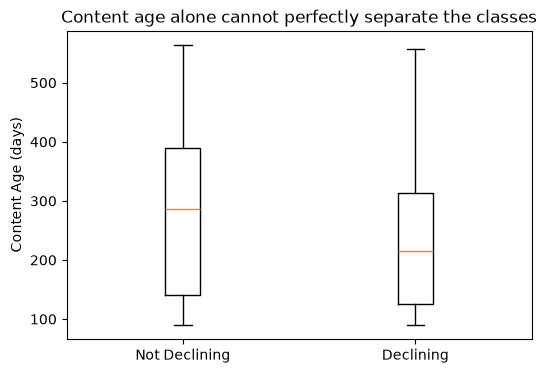

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.boxplot(
    [
        df[df["is_declining_label"] == 0]["content_age_days"],
        df[df["is_declining_label"] == 1]["content_age_days"],
    ],
    tick_labels=["Not Declining", "Declining"]
)

plt.ylabel("Content Age (days)")
plt.title("Content age alone cannot perfectly separate the classes")
plt.show()


The distributions overlap substantially. Although content age may contain useful information, it cannot by itself distinguish declining from non-declining pages. Therefore, refresh priority must depend on multiple interacting features rather than a single threshold.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.